In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')

print("Dataset:")
print(dataset)


Dataset:
            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [3]:
X = dataset.iloc[:, 1:2].values   
y = dataset.iloc[:, 2].values     

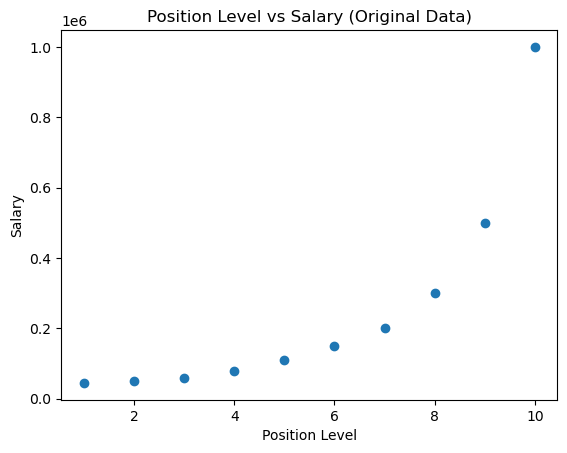

In [4]:
plt.scatter(X, y)
plt.title("Position Level vs Salary (Original Data)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [6]:
poly = PolynomialFeatures(degree=4)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [7]:
model = LinearRegression()

model.fit(X_train_poly, y_train)


LinearRegression()

In [8]:
y_pred = model.predict(X_test_poly)

print("Predicted values:", y_pred)

Predicted values: [ 62618.4898424  554488.61683465]


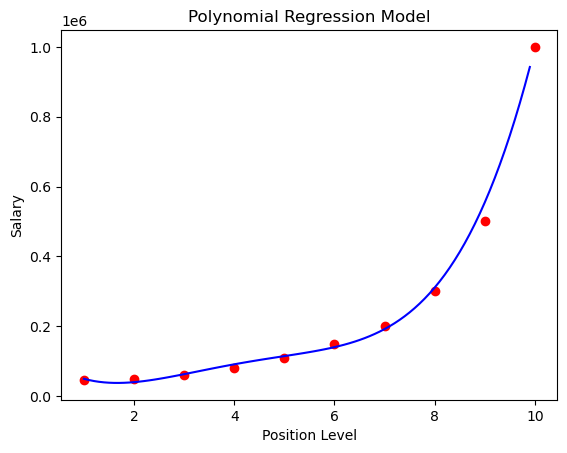

In [9]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)

plt.scatter(X, y, color='red')
plt.plot(X_grid, model.predict(poly.transform(X_grid)), color='blue')

plt.title("Polynomial Regression Model")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

In [10]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9692575841569405


In [11]:
level = 6.5
salary_prediction = model.predict(poly.transform([[level]]))

print("Predicted salary for level", level, "is:", salary_prediction)

Predicted salary for level 6.5 is: [160454.59685743]
